In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("OnlineRetail.CSV", encoding="latin1")


In [ ]:
import os

print(os.getcwd())

c:\Users\Poornima\OneDrive\Desktop\VS_Sample\venv


In [6]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Poornima\OneDrive\Desktop\VS_Sample\OnlineRetail.csv",
    encoding="latin1"
)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [4]:
# Display first 5 rows
print(df.head())

NameError: name 'df' is not defined

In [12]:
# First 5 rows
print(df.head())


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [ ]:
# Last 5 rows
print(df.tail())

       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899     CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254    CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255  CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138    BAKING SET 9 PIECE RETROSPOT          3   

             InvoiceDate  UnitPrice  CustomerID Country  
541904  09-12-2011 12:50       0.85     12680.0  France  
541905  09-12-2011 12:50       2.10     12680.0  France  
541906  09-12-2011 12:50       4.15     12680.0  France  
541907  09-12-2011 12:50       4.15     12680.0  France  
541908  09-12-2011 12:50       4.95     12680.0  France  


In [1]:
# Shape
print(df.shape)

NameError: name 'df' is not defined

In [15]:
# Column names
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [23]:
# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],
format="%d-%m-%Y %H:%M")
print(df["InvoiceDate"].head(5))
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour


0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]


In [32]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove negative Quantity
df = df[df["Quantity"] > 0]

# Remove invalid UnitPrice
df = df[df["UnitPrice"] > 0]

print(df.shape)

(392692, 12)


In [ ]:
#Task 2 – Data Cleaning

In [27]:
# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])
# Check missing values
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Year           0
Month          0
Day            0
Hour           0
dtype: int64


In [34]:
# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])
# Remove duplicate rows
df = df.drop_duplicates()

# Remove negative Quantity
df = df[df["Quantity"] > 0]

# Remove invalid UnitPrice
df = df[df["UnitPrice"] > 0]

print(df.shape)

(392692, 12)


In [ ]:
#Task 3 – Feature Engineering

In [36]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

In [37]:
df["CustomerSegment"] = np.where(
    df["TotalPrice"] > 100,
    "High Value",
    "Regular"
)

In [38]:
df["OrderSize"] = np.where(
    df["Quantity"] > 10,
    "Large",
    "Small"
)

In [39]:
df["DayType"] = np.where(
    df["InvoiceDate"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

In [ ]:

#Task 4 – Data Exploration

In [42]:
#Describe Data
print(df.describe())

            Quantity                 InvoiceDate      UnitPrice  \
count  392692.000000                      392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892       3.125914   
min         1.000000         2010-12-01 08:26:00       0.001000   
25%         2.000000         2011-04-07 11:12:00       1.250000   
50%         6.000000         2011-07-31 12:02:00       1.950000   
75%        12.000000         2011-10-20 12:53:00       3.750000   
max     80995.000000         2011-12-09 12:50:00    8142.750000   
std       180.492832                         NaN      22.241836   

          CustomerID           Year          Month            Day  \
count  392692.000000  392692.000000  392692.000000  392692.000000   
mean    15287.843865    2010.934631       7.601871      15.044656   
min     12346.000000    2010.000000       1.000000       1.000000   
25%     13955.000000    2011.000000       5.000000       7.000000   
50%     15150.000000    2011.000000       8.000000 

In [43]:
#Unique Countries
print(df["Country"].unique())

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',               'Greece',            'Singapore',
              'Lebanon', 'United Arab Emirates',               'Israel',
         'Saudi Arabia',       'Czech Republic',               'Canada',
          'Unspecified',               'Brazil',                  'USA',
   'European Community',              'Bahrain',                'Malta',
                  'RSA']
Length: 37, dtype: str


In [46]:
#Count Countries
print(df["Country"].value_counts())

Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


In [47]:
#Sales by Country
country_sales = df.groupby("Country")["TotalPrice"].sum()
print(country_sales)

Country
Australia                138453.810
Austria                   10198.680
Bahrain                     548.400
Belgium                   41196.340
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20440.540
Cyprus                    13502.850
Czech Republic              826.740
Denmark                   18955.340
EIRE                     265262.460
European Community         1300.250
Finland                   22546.080
France                   208934.310
Germany                  228678.400
Greece                     4760.520
Iceland                    4310.000
Israel                     7215.840
Italy                     17483.240
Japan                     37416.370
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2725.590
Netherlands              285446.340
Norway                    36165.440
Poland                     7334.650
Portugal                  33375.840
RSA                 

In [49]:
#Sales by Month
month_sales = df.groupby("Month")["TotalPrice"].sum()
print(month_sales)

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64


In [51]:
#Top Products
product_sales = df.groupby("Description")["Quantity"].sum()
print(product_sales.sort_values(ascending=False).head())

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: Quantity, dtype: int64


In [53]:
#Task 5 – Data Wrangling
#Top Customers

top_customers = df.groupby("CustomerID")["TotalPrice"].sum()

print(top_customers.sort_values(ascending=False).head(4))

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
Name: TotalPrice, dtype: float64


In [54]:
#Top Countries
top_countries = df.groupby("Country")["TotalPrice"].sum()

print(top_countries.sort_values(ascending=False).head(4))

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
Name: TotalPrice, dtype: float64


In [56]:
#Task 6 – Statistical Analysis
print("Mean:", df["Quantity"].mean())
print("Median:", df["Quantity"].median())
print("Mode:", df["Quantity"].mode()[0])

Mean: 13.1197019547126
Median: 6.0
Mode: 1


In [57]:
#Total Price
print("Standard Deviation:", df["TotalPrice"].std())
print("Variance:", df["TotalPrice"].var())

Standard Deviation: 311.09922433480364
Variance: 96782.72738171647


In [58]:
#Percentiles
print(df["TotalPrice"].quantile([0.25,0.50,0.75]))

0.25     4.95
0.50    12.45
0.75    19.80
Name: TotalPrice, dtype: float64


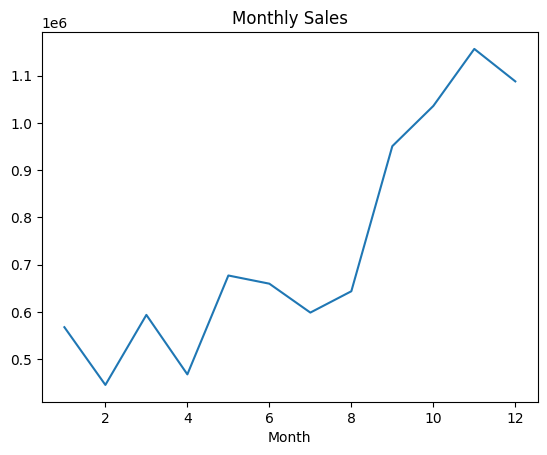

In [60]:
#Task 7 – Data Visualization
#1. Line Chart
month_sales.plot(kind="line")

plt.title("Monthly Sales")
plt.show()

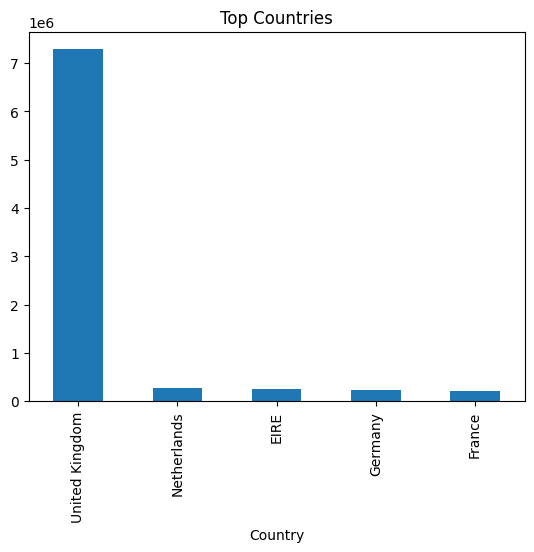

In [62]:
#2. Bar Chart
top_countries.sort_values(ascending=False).head(5).plot(kind="bar")

plt.title("Top Countries")
plt.show()

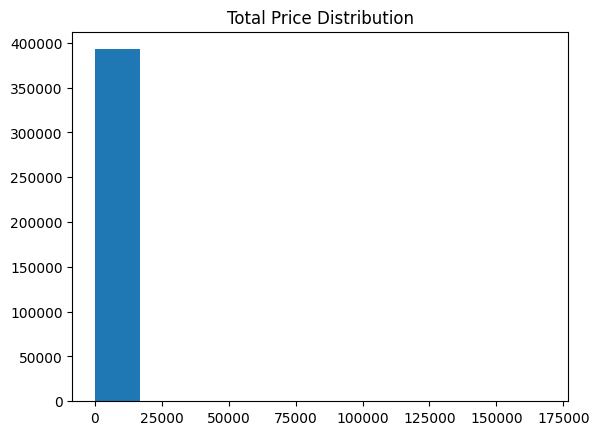

In [64]:
#3. Histogram
plt.hist(df["TotalPrice"], bins=10)

plt.title("Total Price Distribution")
plt.show()

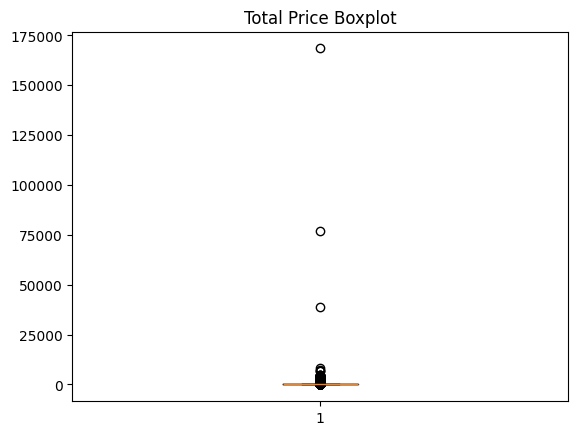

In [67]:
#4. Box Plot
plt.boxplot(df["TotalPrice"])
plt.title("Total Price Boxplot")
plt.show()

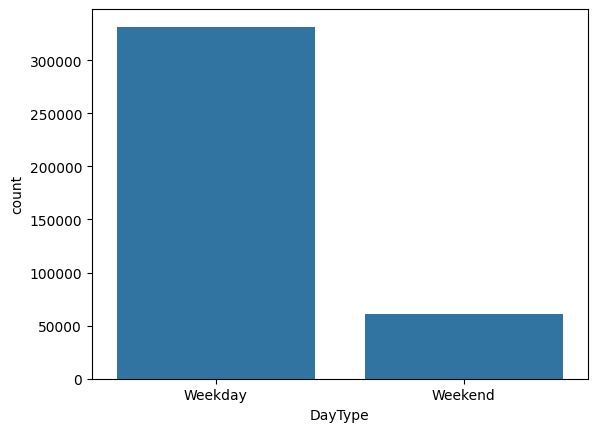

In [69]:
#5. Count Plot
sns.countplot(x="DayType", data=df)

plt.show()

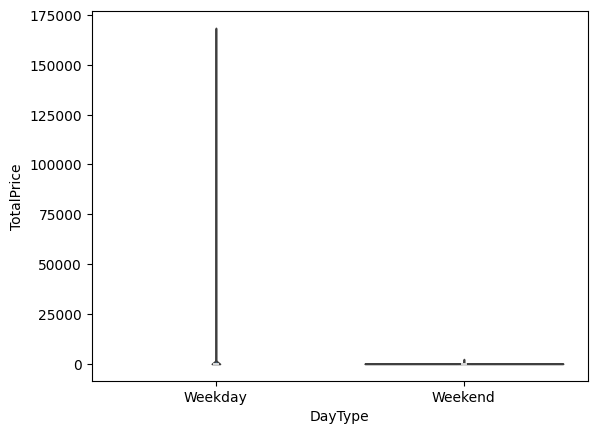

In [70]:
#6. Violin Plot
sns.violinplot(x="DayType", y="TotalPrice", data=df)

plt.show()

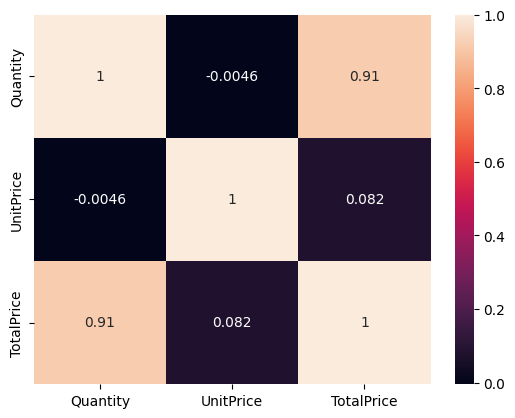

In [72]:
#7. Heatmap
corr = df[["Quantity","UnitPrice","TotalPrice"]].corr()

sns.heatmap(corr, annot=True)

plt.show()

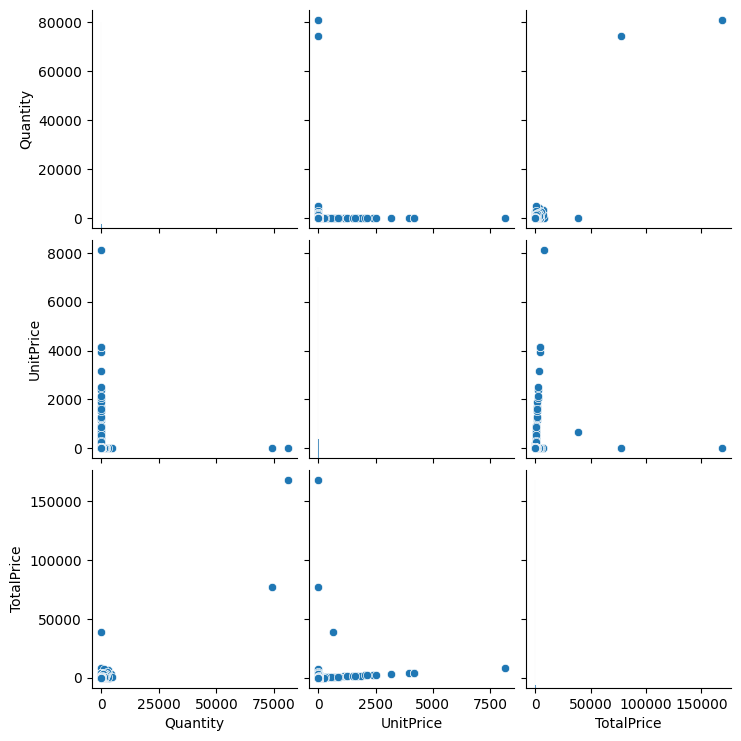

In [73]:
#8. Pair Plot
sns.pairplot(
    df[["Quantity","UnitPrice","TotalPrice"]]
)

plt.show()

In [ ]:
#Task 8 – Business Insights
#Top Country by Sales
print(df.groupby("Country")["TotalPrice"].sum().idxmax())

United Kingdom


In [76]:
#Best Sales Month
print(df.groupby("Month")["TotalPrice"].sum().idxmax())

11


In [75]:
#Peak Sales Hour
print(df.groupby("Hour")["TotalPrice"].sum().idxmax())

12


In [77]:
#High Value Customers
high_value_customers = df[df["CustomerSegment"] == "High Value"]["CustomerID"].unique()
print(high_value_customers)

[13748. 15100. 15291. ... 13298. 14569. 16446.]


In [78]:
high_customers = df.groupby("CustomerID")["TotalPrice"].sum()

print(high_customers.sort_values(ascending=False).head(10))

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [79]:
#Top Products
top_products = df.groupby("Description")["Quantity"].sum()

print(top_products.sort_values(ascending=False).head(10))

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


git config --global user.email
